**Imputation of missing data**

For this step I need to look at the current data and identify:
- the number of missing values
- the measure of inserting a value to compensate for the lack of variable


In [15]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [71]:
data= pd.read_csv("C:/Users/jamie/Documents/Data_Analysis_and_Visualisation/DAV_CA1/world_record_factors_17_05_26.csv")

In [72]:
print(data.info())
data.head(30)


<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Game_Name            30 non-null     str    
 1   Total_Runs           30 non-null     int64  
 2   World_record_time    30 non-null     str    
 3   World_record_age     30 non-null     int64  
 4   World_record_margin  30 non-null     str    
 5   Casual_Completion    26 non-null     float64
 6   Glitches_possible    30 non-null     str    
 7   Platform             29 non-null     str    
 8   Category             30 non-null     str    
 9   Active_Runners       30 non-null     int64  
 10  RNG                  30 non-null     int64  
dtypes: float64(1), int64(4), str(6)
memory usage: 2.7 KB
None


,Game_Name,Total_Runs,World_record_time,World_record_age,World_record_margin,Casual_Completion,Glitches_possible,Platform,Category,Active_Runners,RNG
0,Super Mario 64,52653,00:14:35,1153,00:00:01,12.0,Yes,N64,Platformer,384,1
1,Celeste,50501,00:24:48,39,00:00:15,8.5,No,PC,Platformer,419,1
2,Super Mario Odyssey,22934,00:55:13,304,00:00:05,12.5,Yes,Switch2,Platformer,172,1
3,Getting over it with Bennett Foddy,15086,00:00:58,340,00:00:01,6.0,No,PC,Platformer,140,1
4,Spongebob Squarepants: Battle for Bikini Bottom,14817,00:40:37,241,00:01:55,10.0,Yes,Xbox,Platformer,29,1
5,Super Metroid,13932,00:40:22,472,00:00:14,7.5,Yes,SNES,Platformer,65,1
6,Hollow Knight,13099,00:30:49,376,00:00:04,27.0,Yes,PC,Platformer,163,1
7,Super Mario World,11247,00:32:18,247,00:00:02,5.0,Yes,SNES,Platformer,28,1
8,Sonic Adventure 2: Battle,11190,00:20:53,1296,00:00:05,9.0,Yes,PC,Platformer,47,1
9,Mighty guy 3,2,00:02:08,1571,00:00:10,NaN,No,PC,Platformer,0,1


In [73]:
data.isnull().sum()


Game_Name              0
Total_Runs             0
World_record_time      0
World_record_age       0
World_record_margin    0
Casual_Completion      4
Glitches_possible      0
Platform               1
Category               0
Active_Runners         0
RNG                    0
dtype: int64

- There are 5 values that are missing within this dataset, using a heatmap I can identify where these missing values reside

<Axes: >

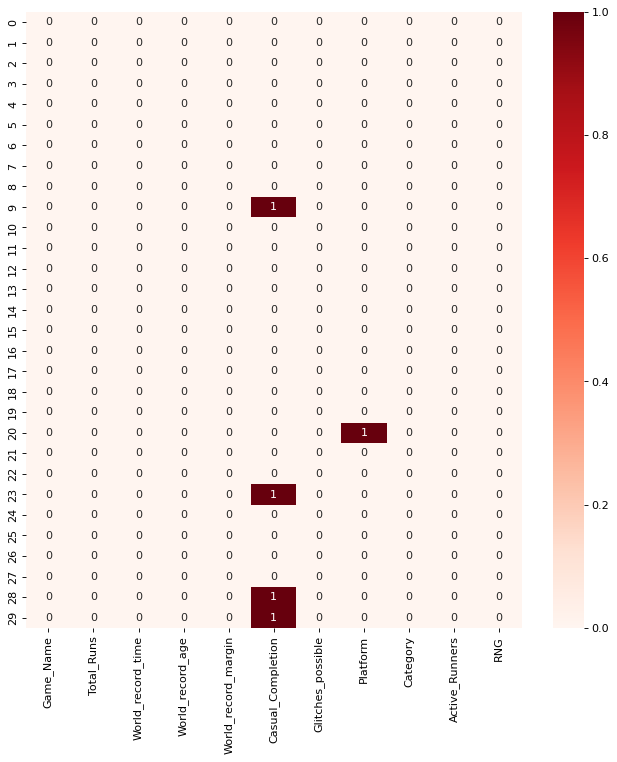

In [74]:
plt.figure(num=None, figsize=(10, 10), dpi=80)
sns.heatmap(data.isnull() ,annot=True, cmap="Reds")

- To ensure that we have a complete dataset for our index we will fill this data by means of the mean value
- I have identified that there are 2 categories that contain missing values, **Casual completion** and **Platform**

In [75]:
data["Casual_Completion"] = data["Casual_Completion"].fillna(data["Casual_Completion"].mean())
data["Platform"]= data["Platform"].fillna(data["Platform"].mode()[0])

data.isnull().sum()



Game_Name              0
Total_Runs             0
World_record_time      0
World_record_age       0
World_record_margin    0
Casual_Completion      0
Glitches_possible      0
Platform               0
Category               0
Active_Runners         0
RNG                    0
dtype: int64

- Now that I have a complete dataset I need to check for outliers

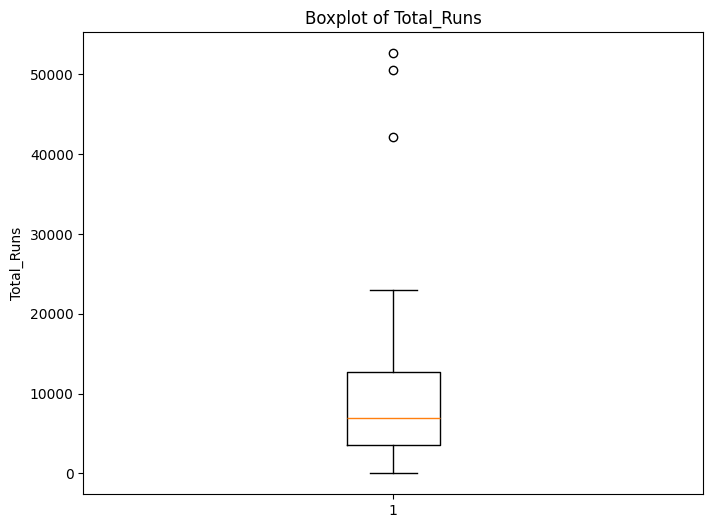

In [82]:
plt.figure(num=None, figsize=(8, 6), dpi=100, facecolor="w", edgecolor="k")
plt.boxplot(x = data.Total_Runs)
plt.title("Boxplot of Total_Runs")
plt.ylabel("Total_Runs")
plt.show()

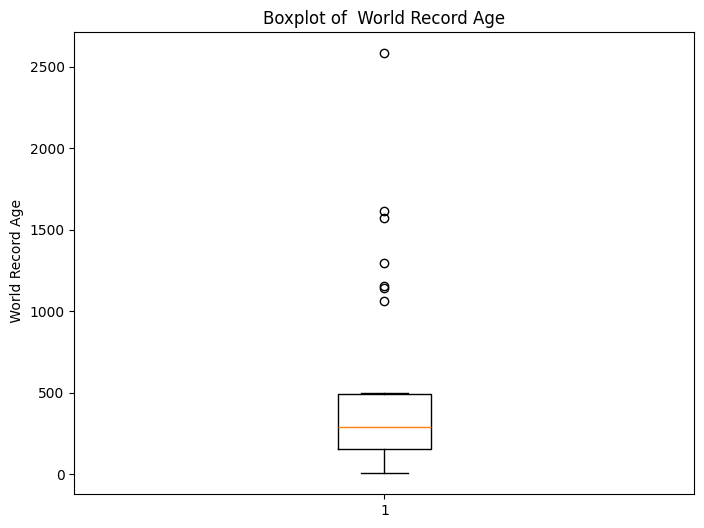

In [84]:
plt.figure(num=None, figsize=(8, 6), dpi=100, facecolor="w", edgecolor="k")
plt.boxplot(x = data.World_record_age)
plt.title("Boxplot of  World Record Age")
plt.ylabel(" World Record Age")
plt.show()

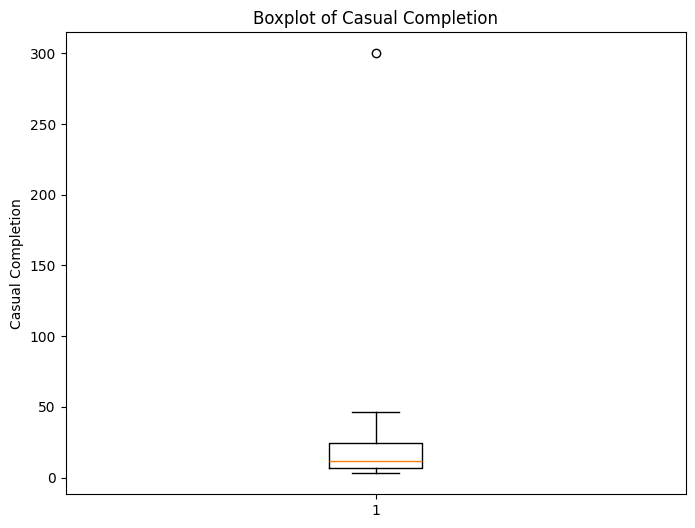

In [85]:
plt.figure(num=None, figsize=(8, 6), dpi=100, facecolor="w", edgecolor="k")
plt.boxplot(x = data.Casual_Completion)
plt.title("Boxplot of Casual Completion")
plt.ylabel("Casual Completion")
plt.show()

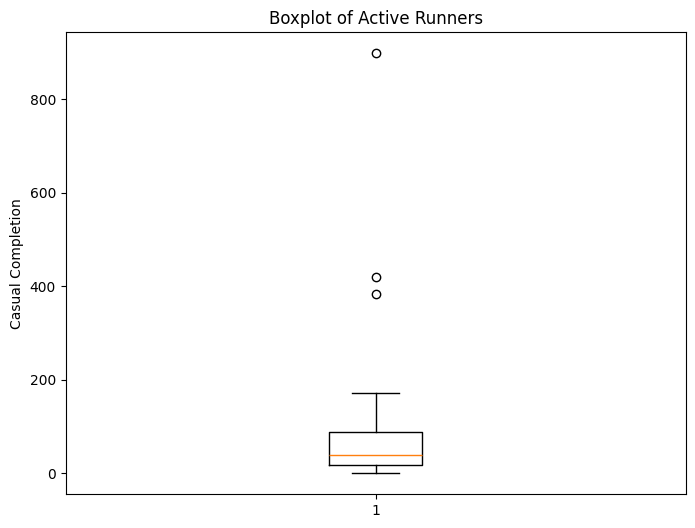

In [86]:
plt.figure(num=None, figsize=(8, 6), dpi=100, facecolor="w", edgecolor="k")
plt.boxplot(x = data.Active_Runners)
plt.title("Boxplot of Active Runners")
plt.ylabel("Casual Completion")
plt.show()